<a href="https://colab.research.google.com/github/Vinicius-Araujppp/trabalho-mineracao-dados-jaqueline1bimestre/blob/main/02_regressao_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de Mineração de Dados - 1º Bimestre
**Tarefa:** Regressão
**Base de dados:** Custos Médicos (insurance.csv)
## 1. Introdução
Este notebook tem como objetivo prever os custos hospitalares (charges) com base em variáveis socioeconômicas e de saúde. Utilizaremos a penalização Lasso (L1) como algoritmo embutido para seleção de atributos, buscando remover variáveis irrelevantes.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Carregar dados a partir da pasta data/raw
df = pd.read_csv('data/raw/insurance.csv')
X = df.drop('charges', axis=1)
y = df['charges']

# Exploração inicial
print("Dimensão dos dados:", df.shape)
print("Valores ausentes por coluna:")
print(df.isna().sum())
print("Estatísticas das variáveis numéricas:")
display(df.describe().T)
print("Distribuição das variáveis categóricas:")
for coluna in ['sex', 'smoker', 'region']:
    print(f"\n{coluna}:")
    print(df[coluna].value_counts())

# Divisão 80/20 antes do pré-processamento
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pré-processamento ajustado apenas no conjunto de treino
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)])

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

Dimensão dos dados: (1338, 7)
Valores ausentes por coluna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Estatísticas das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


Distribuição das variáveis categóricas:

sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Regressão Linear com todas as colunas codificadas
modelo_lin = LinearRegression()
modelo_lin.fit(X_train, y_train)
y_pred_lin = modelo_lin.predict(X_test)

print("R2 Inicial:", r2_score(y_test, y_pred_lin))
print("RMSE Inicial:", np.sqrt(mean_squared_error(y_test, y_pred_lin)))

R2 Inicial: 0.7835929767120722
RMSE Inicial: 5796.284659276275


In [3]:
from sklearn.linear_model import Lasso

# Lasso (L1) para seleção embutida de atributos
modelo_lasso = Lasso(alpha=100.0, random_state=42)
modelo_lasso.fit(X_train, y_train)
y_pred_lasso = modelo_lasso.predict(X_test)

print("R2 Lasso:", r2_score(y_test, y_pred_lasso))
print("RMSE Lasso:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))

# Seleção explícita dos atributos com coeficiente não nulo
nomes_atributos = preprocessor.get_feature_names_out()
mascara_selecao = np.abs(modelo_lasso.coef_) > 1e-6
atributos_selecionados = nomes_atributos[mascara_selecao]
print("Atributos selecionados pelo Lasso:")
print(list(atributos_selecionados))
print("Quantidade de atributos selecionados:", mascara_selecao.sum())

# Treinamento e avaliação de um modelo final apenas com os atributos selecionados
X_train_selecionado = X_train[:, mascara_selecao]
X_test_selecionado = X_test[:, mascara_selecao]
modelo_final = LinearRegression()
modelo_final.fit(X_train_selecionado, y_train)
y_pred_final = modelo_final.predict(X_test_selecionado)

print("R2 Modelo Final com Seleção:", r2_score(y_test, y_pred_final))
print("RMSE Modelo Final com Seleção:", np.sqrt(mean_squared_error(y_test, y_pred_final)))

R2 Lasso: 0.7792828181421608
RMSE Lasso: 5853.722106648779
Atributos selecionados pelo Lasso:
['num__age', 'num__bmi', 'num__children', 'cat__smoker_yes']
Quantidade de atributos selecionados: 4
R2 Modelo Final com Seleção: 0.7811147722517887
RMSE Modelo Final com Seleção: 5829.378521780666


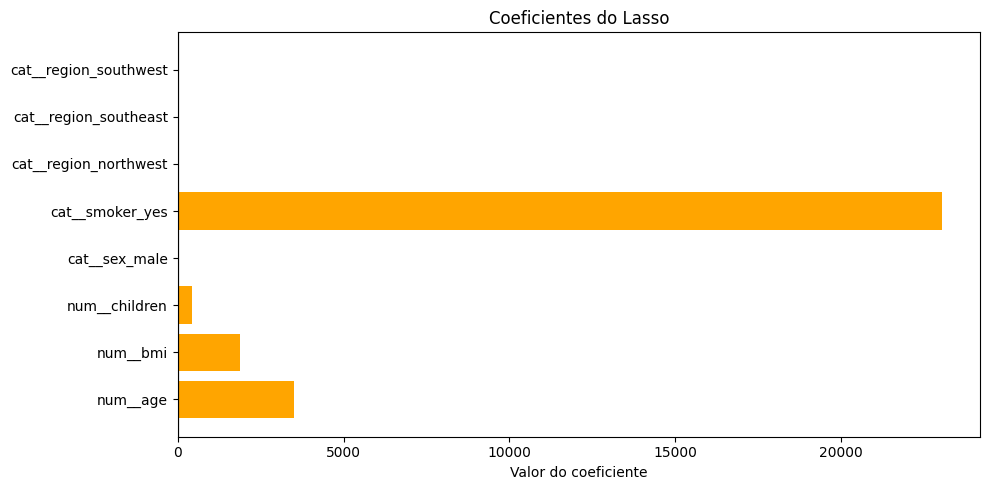

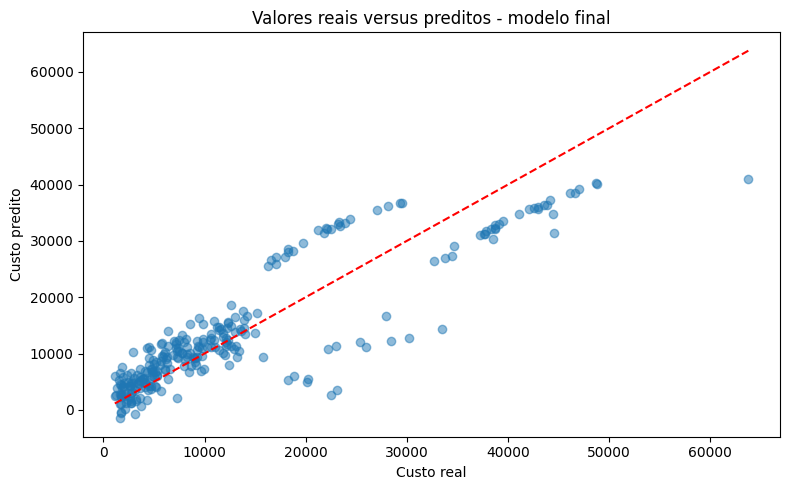

,Modelo,R2,RMSE
0,Linear inicial,0.783593,5796.284659
1,Lasso,0.779283,5853.722107
2,Final com seleção,0.781115,5829.378522


In [4]:
import matplotlib.pyplot as plt

# Coeficientes do Lasso para visualizar os atributos selecionados
plt.figure(figsize=(10, 5))
plt.barh(nomes_atributos, modelo_lasso.coef_, color='orange')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes do Lasso')
plt.xlabel('Valor do coeficiente')
plt.tight_layout()
plt.show()

# Valores reais versus preditos pelo modelo final
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Valores reais versus preditos - modelo final')
plt.xlabel('Custo real')
plt.ylabel('Custo predito')
plt.tight_layout()
plt.show()

# Comparação das métricas dos modelos
metricas = pd.DataFrame({
    'Modelo': ['Linear inicial', 'Lasso', 'Final com seleção'],
    'R2': [r2_score(y_test, y_pred_lin), r2_score(y_test, y_pred_lasso), r2_score(y_test, y_pred_final)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lin)), np.sqrt(mean_squared_error(y_test, y_pred_lasso)), np.sqrt(mean_squared_error(y_test, y_pred_final))]
})
display(metricas)

## 7. Discussão dos resultados

A tabela final compara o modelo linear inicial, o Lasso e o modelo final treinado apenas com os atributos cujo coeficiente do Lasso não foi zerado. O R² mede a proporção da variação dos custos explicada pelo modelo, enquanto o RMSE penaliza mais fortemente erros grandes. A seleção deve ser avaliada pelo equilíbrio entre desempenho preditivo e redução da quantidade de atributos, e não apenas pela busca do maior R².

## 8. Conclusão

O Lasso foi usado como método embutido de seleção de atributos e identificou as variáveis com coeficientes não nulos. Em seguida, um modelo final foi treinado somente com esse subconjunto, permitindo comparar diretamente o desempenho com o modelo linear inicial. A análise conjunta de R², RMSE, gráficos e quantidade de atributos mostra se a redução de complexidade compensa eventual perda de desempenho.